In [1]:
import zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

# --- Adjust this if your zip is elsewhere ---
ZIP_PATH = Path("../../../../to-check-poject/data/adult.zip")  # or "/mnt/data/adult.zip" in your environment

# Column names from the UCI Adult dataset
COLS = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

# Helper to read a CSV inside the zip
def read_from_zip(zip_path, member_name, cols, skip_rows=0):
    with zipfile.ZipFile(zip_path) as z:
        with z.open(member_name) as f:
            df = pd.read_csv(
                f,
                header=None,
                names=cols,
                na_values=["?"," ?"],
                skiprows=skip_rows,
                skipinitialspace=True
            )
    # strip whitespace from string columns
    for c in df.select_dtypes(include="object"):
        df[c] = df[c].str.strip()
    return df

# Find likely data files inside the zip
with zipfile.ZipFile(ZIP_PATH) as z:
    members = z.namelist()
members


['Index', 'adult.data', 'adult.names', 'adult.test', 'old.adult.names']

In [3]:
# Try to locate standard file names
train_member = next((m for m in members if "adult.data" in m), None)
test_member  = next((m for m in members if "adult.test" in m), None)

# Read training data (UCI adult.data has no header row)
df_train = read_from_zip(ZIP_PATH, train_member, COLS)

# Read test data (UCI adult.test has one header/comment row to skip)
df_test  = read_from_zip(ZIP_PATH, test_member, COLS, skip_rows=1)

# Merge to have full EDA sample (common approach for EDA only)
df = pd.concat([df_train, df_test], ignore_index=True)

# The test labels often end with a dot ">50K." -> normalize to match training labels (>50K / <=50K)
if df["income"].dtype == "object":
    df["income"] = df["income"].str.replace(".", "", regex=False)

df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# First & last 5 rows
display(df.head())
display(df.tail())

# Shape
print("Shape:", df.shape)

# Dtypes
print("\nDtypes:\n", df.dtypes)

# Unique counts per column
print("\nUnique counts:\n", df.nunique())

# Summary statistics (numeric)
display(df.describe())

# Summary for categoricals (top few levels)
for col in df.select_dtypes(include="object"):
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False).head(10))


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K


Shape: (48842, 15)

Dtypes:
 age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Unique counts:
 age                  74
workclass             8
fnlwgt            28523
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        123
capital-loss         99
hours-per-week       96
native-country       41
income                2
dtype: int64


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000



Value counts for workclass:
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Value counts for education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

Value counts for marital-status:
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

Value counts for occupation:
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-c

In [5]:
# Missing values count & percentage
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": na_counts, "missing_%": na_pct})
display(missing_report[missing_report["missing_count"] > 0])


,missing_count,missing_%
occupation,2809,5.75
workclass,2799,5.73
native-country,857,1.75


In [6]:
# OPTION A — Deletion
#df_dropna = df.dropna(subset=["workclass", "occupation", "native-country"])

# OPTION B — Imputation (string columns only, use "Unknown")
df_impute = df.copy()
for col in ["workclass", "occupation", "native-country"]:
    df_impute[col] = df_impute[col].fillna("Unknown")

# Choose the one you’ll continue with for EDA:
df_eda = df_impute  # or df_impute
print("EDA dataframe shape:", df_eda.shape)


EDA dataframe shape: (48842, 15)


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class proportions (%):
 income
<=50K    76.07
>50K     23.93
Name: count, dtype: float64


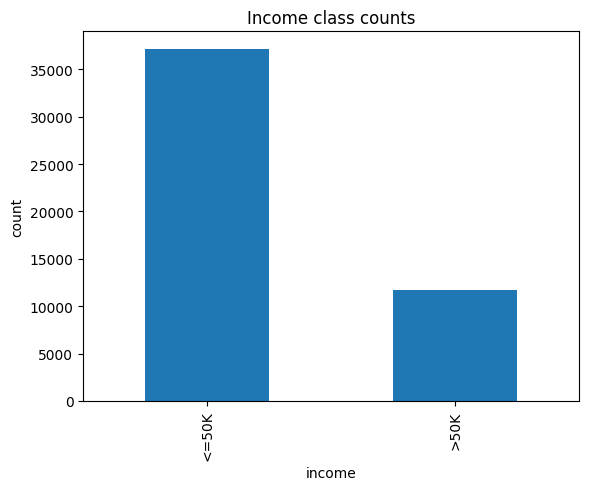

In [7]:
vc = df_eda["income"].value_counts()
print(vc)
print("\nClass proportions (%):\n", (vc / vc.sum() * 100).round(2))

# Bar chart
vc.plot(kind="bar")
plt.title("Income class counts")
plt.xlabel("income")
plt.ylabel("count")
plt.show()


In [ ]:
df_eda = df_eda.drop(columns=["fnlwgt"])

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_eda.select_dtypes(include="object").columns.tolist()
cat_cols.remove("income")  # target is categorical but treat separately

numeric_cols, cat_cols


In [ ]:
for col in numeric_cols:
    fig, ax = plt.subplots()
    df_eda[col].hist(ax=ax, bins=30)
    ax.set_title(f"Histogram: {col}  (skew={df_eda[col].skew():.2f})")
    ax.set_xlabel(col); ax.set_ylabel("count")
    plt.show()

    fig, ax = plt.subplots()
    ax.boxplot(df_eda[col].dropna(), vert=True)
    ax.set_title(f"Boxplot: {col}")
    ax.set_ylabel(col)
    plt.show()


In [ ]:
for col in cat_cols:
    counts = df_eda[col].value_counts(dropna=False)
    print(f"\n{col} — unique={counts.shape[0]}")
    print(counts.head(15))


In [ ]:
def iqr_outlier_counts(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_lower = (s < lower).sum()
    n_upper = (s > upper).sum()
    return pd.Series({"lower_thr": lower, "upper_thr": upper, "n_lower": n_lower, "n_upper": n_upper})

outlier_table = pd.concat([iqr_outlier_counts(df_eda[col]) for col in numeric_cols], axis=1).T
outlier_table.index = numeric_cols
display(outlier_table)


In [ ]:
transform_candidates = ["capital-gain", "capital-loss"]
df_trans = df_eda.copy()
for col in transform_candidates:
    df_trans[col + "_log1p"] = np.log1p(df_trans[col])

for col in transform_candidates:
    fig, ax = plt.subplots()
    df_trans[col + "_log1p"].hist(ax=ax, bins=30)
    ax.set_title(f"Histogram (log1p): {col}")
    plt.show()

# If you decide to keep transformed versions for later modeling:
df_eda = df_trans


In [ ]:
corr = df_eda[numeric_cols].corr()
corr


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
plt.title("Correlation heatmap (numeric)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [ ]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / max(1e-12, min((kcorr-1), (rcorr-1))))

assoc = []
for col in cat_cols:
    assoc.append((col, cramers_v(df_eda[col], df_eda["income"])))
assoc = sorted(assoc, key=lambda x: x[1], reverse=True)
assoc


In [ ]:
# Hours per week by income (boxplot)
fig, ax = plt.subplots()
groups = [df_eda.loc[df_eda["income"]==k, "hours-per-week"].dropna() for k in ["<=50K", ">50K"]]
ax.boxplot(groups, labels=["<=50K", ">50K"])
ax.set_title("Hours-per-week vs income")
ax.set_ylabel("hours-per-week")
plt.show()

# Education vs income (stacked bar)
ct = pd.crosstab(df_eda["education"], df_eda["income"], normalize="index").sort_values(">50K", ascending=False)
ct.plot(kind="bar", stacked=True)
plt.title("P(income | education)")
plt.ylabel("proportion")
plt.tight_layout()
plt.show()
